In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.io import loadmat
import xarray as xr
import pandas as pd
import os
import sys
import cv2
import glob
%load_ext autoreload
%autoreload 2
%matplotlib inline
import os, sys
sys.path.append(os.getcwd())
os.chdir("../..")
savedir = os.path.join(os.getcwd(),"DATA")
path = os.getcwd()
path = os.path.join(path,"DATA/SIOS21/")
# Open ADCP data
ds_adcp = xr.open_dataset(os.path.join(path,"adcp_data_and_analysis_lars_smedsrud/Nortek_ADCP_currents_Oct20_to_Nov4_avgd_cal.nc"))

path_p = os.path.join(path,"MARS_ICE02_034/MARS_ICE02_034_CSV/")
file_p = "MARS_ICE02_034_1_telemetry.gssbin_OPENINS_PRESSURE_STAT.nc"
path_v = os.path.join(path,"MARS_ICE02_034/")
file_v_t = "video_timing_UTC.csv" # video timing
netcdf_path = os.path.join(path_v, "netcdf_frazil_data")
# Open the frazil data from Icefin
ds_icefin = xr.open_dataset(os.path.join(path,'MARS_ICE02_034/netcdf_frazil_data/MARS_ICE02_034_1_box_4_thresh_40_stats_all.nc'))
# Open the video timing
video_timing = pd.read_csv(os.path.join(path_v,file_v_t))
# Find out what the start time of ds_icefin was

In [2]:
ds_icefin.rel_area.data

array([0.45619266, 0.00323522, 0.00177684, 0.00476373, 0.00886802,
       0.01340563, 0.02690664, 0.02060463])

In [3]:
# FIX-ME: time range manually inserted because of data storing issues
# denote start and end times of first and last video selections from Icefin/analyze_Nov3.ipynb 
start_time = pd.to_datetime("2021-11-03 01:54:24.650715136")
end_time = pd.to_datetime("2021-11-03 03:16:09.764978603")

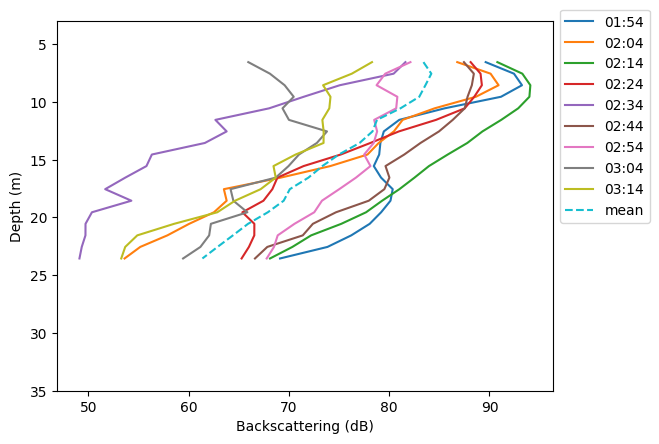

In [4]:
# select the ADCP data acquired within the time span of the selected videos and visualize
adcp_video_sel = ds_adcp.sel(time=slice(start_time, end_time))
BSv = adcp_video_sel.BSv
depth_bins = adcp_video_sel.depth_bins.mean(axis=1)

fig, ax = plt.subplots()

for i in range(BSv.shape[1]):
    ax.plot(BSv[2:,i], depth_bins[2:], label = str(adcp_video_sel.time[i].dt.strftime('%H:%M').data))

avg_BSv = np.mean(BSv, axis=1)
ax.plot(avg_BSv[2:], depth_bins[2:], label="mean", linestyle="--")

ax.invert_yaxis()
ax.set_xlabel("Backscattering (dB)")
ax.set_ylabel("Depth (m)")
ax.set_ylim([35,3])

# ax.legend(loc="upper left")
ax.legend(bbox_to_anchor=(1., 1.05))
# fig.savefig(os.path.join(save_dir, "ADCP_Icefin_profile_selection.eps"), bbox_inches = "tight")

In [5]:
def crop_by_depth(variable, depth, depth_limit=30):
    """
    Crop a variable and its corresponding depth array to a fixed depth range.

    Parameters
    ----------
    variable : np.ndarray
        The array you want to crop (e.g., number_of_crystals, fractional_frazil_area, etc.).
    depth : np.ndarray
        Depth array aligned with `variable`.
    depth_limit : float, optional
        Hard-coded maximum depth to retain (default: 30 m).

    Returns
    -------
    variable_crop : np.ndarray
        The cropped variable values.
    depth_crop : np.ndarray
        The cropped depths corresponding to the above values.
    """

    mask = depth < depth_limit
    variable_crop = variable[mask]
    depth_crop = depth[mask]
    return variable_crop, depth_crop

In [6]:
# ADCP: Select time and depth matched with 4k 
upper = adcp_video_sel.sel(time = slice(start_time, start_time+pd.Timedelta(11, "minutes")), depth_profile=slice(10.24, 18.24))
middle = adcp_video_sel.sel(time = slice(end_time-pd.Timedelta(12, "minutes"), end_time), depth_profile=slice(18.24, 20.24))
lower = adcp_video_sel.sel(time = slice(end_time-pd.Timedelta(23, "minutes"), 
                                        end_time-pd.Timedelta(11, "minutes")), depth_profile=slice(20.24, 26.24))
assembled_profile = xr.concat([upper, middle, lower], dim="depth_profile")

/tmp/ipykernel_76064/2245012067.py:6: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  assembled_profile = xr.concat([upper, middle, lower], dim="depth_profile")
/tmp/ipykernel_76064/2245012067.py:6: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  assembled_profile = xr.concat([upper, middle, lower], dim="depth_profile")
/tmp/ipykernel_760

In [7]:
# frazil ice concentration: Select upper 25 metres and sort
fractional_frazil_area_crop, depth = crop_by_depth(ds_icefin.rel_area.data, ds_icefin.depth.data)

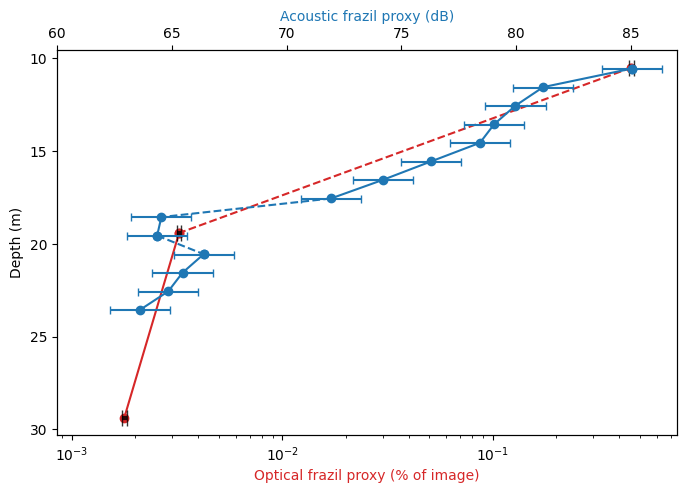

In [8]:
dpixel = 0.5
n_images = 1400
icefin_err = (2*fractional_frazil_area_crop*dpixel)*(1/np.sqrt(n_images))
# adcp_err = 20*np.ones_like(assembled_profile.BSv.mean(axis=1)) # +/- 10 dB (Purdie 2012)
L_min = 0.85 * 10**(assembled_profile.BSv.mean(axis=1)/10) # +/-15% relative error (
L_max = 1.15 * 10**(assembled_profile.BSv.mean(axis=1)/10)
P_min = 10 * np.log10(L_min)
P_max = 10 * np.log10(L_max)
adcp_err = P_max - P_min

# Plot the FFA with log-scale and the backscatter in dB
color1="tab:red"
color2="tab:blue"
fig, ax1 = plt.subplots(figsize = (8,5))
ax1.plot(fractional_frazil_area_crop[0], depth[0], color=color1, marker="o", label ="FFA")
ax1.plot(fractional_frazil_area_crop[0:2], depth[0:2], color=color1, marker="o", linestyle="--")
ax1.plot(fractional_frazil_area_crop[1:], depth[1:], color=color1, marker="o", linestyle="-")
ax1.errorbar(
    fractional_frazil_area_crop, depth,
    xerr=icefin_err,
    fmt='none',
    ecolor='black',      # visible against red markers
    alpha=0.8,
    elinewidth=3,        # much thicker
    capsize=6,
    zorder=3
)

ax1.set_xscale("log")
ax1.invert_yaxis()
ax1.set_ylabel("Depth (m)")
ax1.set_xlabel(r"Optical frazil proxy (% of image)", color=color1)
ax1.set_xlim([0.85e-3, 0.75])
ax2 = ax1.twiny()
ax2.plot(upper.BSv.mean(axis=1)[0], upper.depth_bins.mean(axis=1)[0], color=color2, marker="o",label="Backscatter")
ax2.plot(upper.BSv.mean(axis=1), upper.depth_bins.mean(axis=1), color=color2, marker="o")
ax2.plot([upper.BSv.mean(axis=1)[-1], middle.BSv.mean(axis=1)[0]], [upper.depth_bins.mean(axis=1)[-1], 
                                                                    middle.depth_bins.mean(axis=1)[0]], color=color2, linestyle="--")
ax2.plot(middle.BSv.mean(axis=1), middle.depth_bins.mean(axis=1), color=color2, marker="o")
ax2.plot([middle.BSv.mean(axis=1)[-1], lower.BSv.mean(axis=1)[0]], [middle.depth_bins.mean(axis=1)[-1], 
                                                                    lower.depth_bins.mean(axis=1)[0]], color=color2,
         marker="o", linestyle="--")
ax2.plot(lower.BSv.mean(axis=1), lower.depth_bins.mean(axis=1), color=color2, marker="o")
ax2.errorbar(assembled_profile.BSv.mean(axis=1), assembled_profile.depth_profile,
             xerr = adcp_err,
             yerr = None,
             fmt = 'none',
             ecolor = "tab:blue",
             elinewidth = 1.5,
             capsize = 3,
             zorder = 2
            )
ax2.set_xlim([60,87])
ax2.set_xlabel("Acoustic frazil proxy (dB)", color=color2)
plt.rcParams.update({'font.size': 18})
fig.savefig(savedir+"/Backscatter_and_FFA.png", bbox_inches="tight")

In [9]:
icefin_err

array([1.21922618e-02, 8.64649548e-05, 4.74880077e-05])

In [20]:
# frazil ice concentration: Select upper 25 metres and sort
number_of_crystals, depth = crop_by_depth(ds_icefin.number_of_crystals.data, ds_icefin.depth.data)

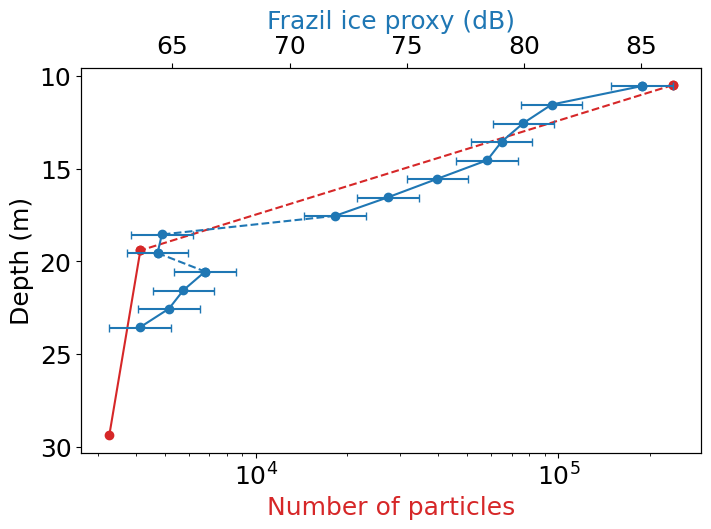

In [21]:
icefin_err = 0.637 * fractional_frazil_area_crop
# adcp_err = 20*np.ones_like(assembled_profile.BSv.mean(axis=1)) # +/- 10 dB (Purdie 2012)
L_min = 0.85 * 10**(assembled_profile.BSv.mean(axis=1)/10) # +/-15% relative error (
L_max = 1.15 * 10**(assembled_profile.BSv.mean(axis=1)/10)
P_min = 10 * np.log10(L_min)
P_max = 10 * np.log10(L_max)
adcp_err = P_max - P_min

# Plot the FFA with log-scale and the backscatter in dB
color1="tab:red"
color2="tab:blue"
fig, ax1 = plt.subplots(figsize = (8,5))
ax1.plot(number_of_crystals[0], depth[0], color=color1, marker="o", label ="FFA")
ax1.plot(number_of_crystals[0:2], depth[0:2], color=color1, marker="o", linestyle="--")
ax1.plot(number_of_crystals[1:], depth[1:], color=color1, marker="o", linestyle="-")
# ax1.errorbar(fractional_frazil_area_crop, depth, 
#              xerr = icefin_err, 
#              yerr=None,
#              fmt='none',              # draw only bars (no markers)
#              ecolor='red',
#              elinewidth=1.5,
#              capsize=3,
#              zorder=2
#             )

ax1.set_xscale("log")
ax1.invert_yaxis()
ax1.set_ylabel("Depth (m)")
ax1.set_xlabel(r"Number of particles", color=color1)
# ax1.set_xlim([2e-8, 8e-5])
# ax2.legend(loc="lower right")
ax2 = ax1.twiny()
ax2.plot(upper.BSv.mean(axis=1)[0], upper.depth_bins.mean(axis=1)[0], color=color2, marker="o",label="Backscatter")
ax2.plot(upper.BSv.mean(axis=1), upper.depth_bins.mean(axis=1), color=color2, marker="o")
ax2.plot([upper.BSv.mean(axis=1)[-1], middle.BSv.mean(axis=1)[0]], [upper.depth_bins.mean(axis=1)[-1], 
                                                                    middle.depth_bins.mean(axis=1)[0]], color=color2, linestyle="--")
ax2.plot(middle.BSv.mean(axis=1), middle.depth_bins.mean(axis=1), color=color2, marker="o")
ax2.plot([middle.BSv.mean(axis=1)[-1], lower.BSv.mean(axis=1)[0]], [middle.depth_bins.mean(axis=1)[-1], 
                                                                    lower.depth_bins.mean(axis=1)[0]], color=color2,
         marker="o", linestyle="--")
ax2.plot(lower.BSv.mean(axis=1), lower.depth_bins.mean(axis=1), color=color2, marker="o")
ax2.errorbar(assembled_profile.BSv.mean(axis=1), assembled_profile.depth_profile,
             xerr = adcp_err,
             yerr = None,
             fmt = 'none',
             ecolor = "tab:blue",
             elinewidth = 1.5,
             capsize = 3,
             zorder = 2
            )
# ax2.plot(assembled_profile, assembled_profile.depth_profile)
ax2.set_xlabel("Frazil ice proxy (dB)", color=color2)
# ax2.set_ylim([35,3])
# ax2.set_xlim([60,88])
# ax2.legend(loc="lower right")
plt.rcParams.update({'font.size': 18})

Text(0.5, 0, 'Particle area (% of image)')

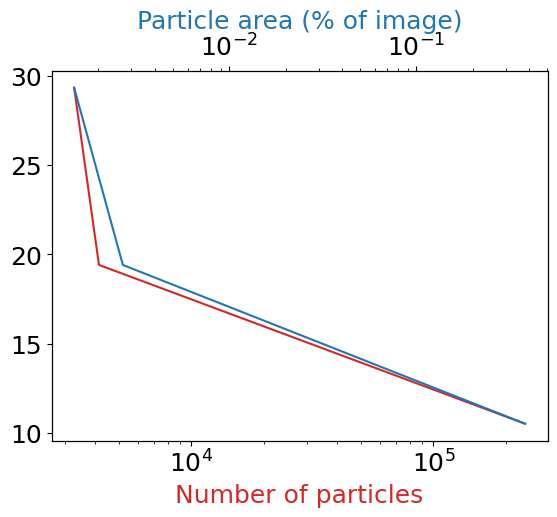

In [23]:
fig, ax1 = plt.subplots()
color1="tab:red"
color2="tab:blue"
ax1.plot(number_of_crystals, depth, color=color1)
ax1.set_xlabel(r"Number of particles", color=color1)
ax1.set_xscale("log")
ax2 = ax1.twiny()
ax2.plot(fractional_frazil_area_crop, depth, color=color2)
ax2.set_xscale("log")
ax2.set_xlabel(r"Particle area (% of image)", color=color2)

Text(0.5, 0, 'Particle area (% of image)')

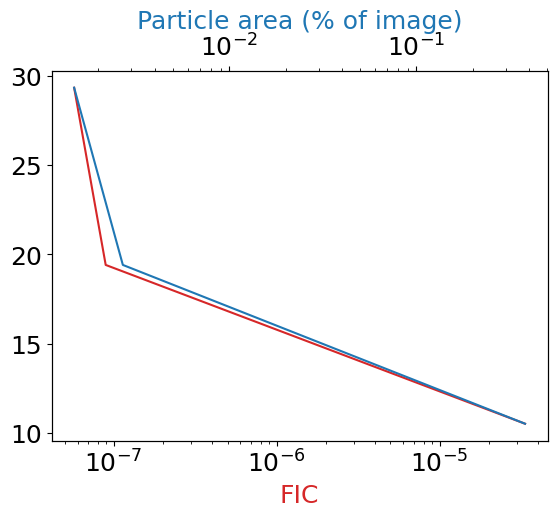

In [25]:
fig, ax1 = plt.subplots()
color1="tab:red"
color2="tab:blue"
ax1.plot(frazil_ice_concentration, depth, color=color1)
ax1.set_xlabel(r"FIC", color=color1)
ax1.set_xscale("log")
ax2 = ax1.twiny()
ax2.plot(fractional_frazil_area_crop, depth, color=color2)
ax2.set_xscale("log")
ax2.set_xlabel(r"Particle area (% of image)", color=color2)